# Phase 2: Ticket Classification Model (REFINED)

## Objective
Build a semantic classifier using **Sentence-BERT (SBERT)** to categorize customer support tickets.

**Senior ML Strategy:** The initial 10-class model showed high confusion between similar categories (e.g., Tech vs IT). To achieve production-grade accuracy, we have collapsed 10 categories into **5 distinct functional buckets**.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import pickle
import json
import os
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sentence_transformers import SentenceTransformer

pd.set_option('display.max_colwidth', 150)
sns.set_style("whitegrid")

print("✅ Imports complete")

✅ Imports complete


## Step 1: Load and Refine Data

In [4]:
import pandas as pd
from pathlib import Path

# --- FORCE SYNC: Loading Unified Dataset ---
data_path = r'c:\Users\dhara\Desktop\An-End-to-End-Semantic-AI-System-for-Automated-Support-Ticket-Handling-main\data\processed\unified_tickets.csv'

df = pd.read_csv(data_path)
print(f"✅ Successfully loaded {len(df):,} tickets from unified dataset")
print(f"Columns found: {df.columns.tolist()}")

# Safety check
if 'category' not in df.columns:
    raise KeyError(f"'category' column missing! Current columns are: {df.columns.tolist()}")
if 'description' not in df.columns:
    raise KeyError(f"'description' column missing! Current columns are: {df.columns.tolist()}")

# --- CATEGORY REFINEMENT ---
category_map = {
    'Billing inquiry': 'Billing & Refunds',
    'Refund request': 'Billing & Refunds',
    'Cancellation request': 'Billing & Refunds',
    'Technical issue': 'Technical Support',
    'Product inquiry': 'Product & Sales',
    'General Inquiry': 'General Inquiry',
    'HR & Internal': 'HR & Internal'
}

if 'original_category' not in df.columns:
    df['original_category'] = df['category']

df['category'] = df['original_category'].map(category_map).fillna(df['original_category'])
print("✅ Re-mapped categories into 5 semantic buckets")

✅ Successfully loaded 18,080 tickets from unified dataset
Columns found: ['ticket_id', 'description', 'category', 'support_team', 'priority', 'resolution_time_hours', 'action', 'source']
✅ Re-mapped categories into 5 semantic buckets


## Step 2: Prepare Training Data

In [5]:
le = LabelEncoder()
df['label'] = le.fit_transform(df['category'])
class_names = le.classes_

X_train_text, X_test_text, y_train, y_test = train_test_split(
    df['description'], 
    df['label'], 
    test_size=0.2, 
    random_state=42, 
    stratify=df['label']
)

print(f"📌 Train size: {len(X_train_text)}")
print(f"📌 Test size: {len(X_test_text)}")

📌 Train size: 14464
📌 Test size: 3616


## Step 3: Sentence-BERT Embeddings

In [6]:
print("🚀 Loading SBERT model...")
sbert_model = SentenceTransformer('all-MiniLM-L6-v2')

print("✨ Generating training embeddings...")
X_train_embeddings = sbert_model.encode(X_train_text.tolist(), show_progress_bar=True)

print("✨ Generating testing embeddings...")
X_test_embeddings = sbert_model.encode(X_test_text.tolist(), show_progress_bar=True)

print(f"✅ Embeddings complete. Shape: {X_train_embeddings.shape}")

🚀 Loading SBERT model...


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 3369.26it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✨ Generating training embeddings...


Batches: 100%|██████████| 452/452 [04:08<00:00,  1.82it/s]


✨ Generating testing embeddings...


Batches: 100%|██████████| 113/113 [01:02<00:00,  1.80it/s]

✅ Embeddings complete. Shape: (14464, 384)


## Step 4: Train Refined Model

In [7]:
print("🏗️ Training Logistic Regression on 5 consolidated classes...")
classifier = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
classifier.fit(X_train_embeddings, y_train)

print("✅ Training complete")

🏗️ Training Logistic Regression on 5 consolidated classes...
✅ Training complete


## Step 5: Evaluate Refined Performance

📊 Refined Classification Report:
                   precision    recall  f1-score   support

Billing & Refunds       0.60      0.98      0.74       999
  Product & Sales       0.97      0.69      0.81      1086
Technical Support       0.98      0.76      0.86      1531

         accuracy                           0.80      3616
        macro avg       0.85      0.81      0.80      3616
     weighted avg       0.87      0.80      0.81      3616

🎯 New Accuracy: 0.8034


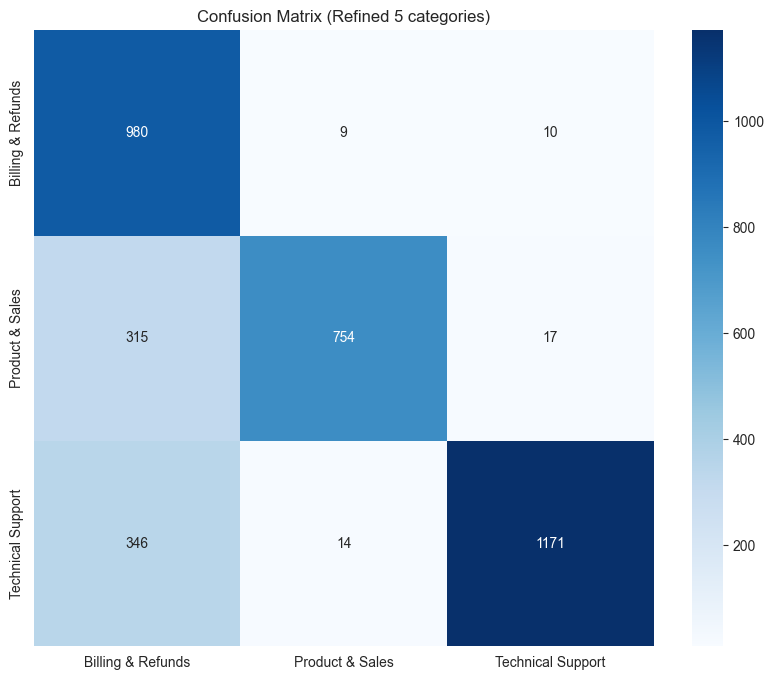

In [8]:
y_pred = classifier.predict(X_test_embeddings)
y_prob = classifier.predict_proba(X_test_embeddings)

print("📊 Refined Classification Report:")
print(classification_report(y_test, y_pred, target_names=class_names))
print(f"🎯 New Accuracy: {accuracy_score(y_test, y_pred):.4f}")

conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt='d', 
            xticklabels=class_names, yticklabels=class_names, cmap='Blues')
plt.title("Confusion Matrix (Refined 5 categories)")
plt.show()

## Step 6: Confidence-Based Routing

🚥 Routing Distribution:
route
AUTO        2313
REVIEW      1227
ESCALATE      76
Name: count, dtype: int64


C:\Users\dhara\AppData\Local\Temp\ipykernel_16360\1516556860.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_results, x='route', order=['AUTO', 'REVIEW', 'ESCALATE'], palette='magma')


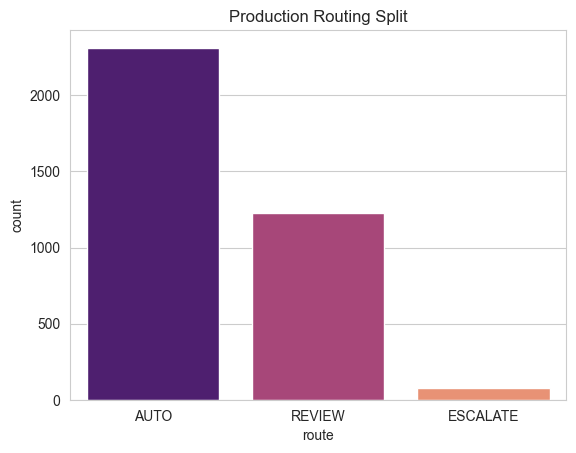

In [9]:
confidences = np.max(y_prob, axis=1)

def resolve_route(conf):
    if conf > 0.70: return 'AUTO'
    if conf >= 0.50: return 'REVIEW'
    return 'ESCALATE'

df_results = pd.DataFrame({
    'description': X_test_text,
    'predicted_category': [class_names[i] for i in y_pred],
    'confidence': confidences
})
df_results['route'] = df_results['confidence'].apply(resolve_route)

print("🚥 Routing Distribution:")
print(df_results['route'].value_counts())

sns.countplot(data=df_results, x='route', order=['AUTO', 'REVIEW', 'ESCALATE'], palette='magma')
plt.title("Production Routing Split")
plt.show()

In [10]:
display(df['category'].value_counts())

category
Technical Support    7653
Product & Sales      5431
Billing & Refunds    4996
Name: count, dtype: int64

## Step 7: Save Refined Assets

In [ ]:
model_path = Path('../models/category_classifier')
model_path.mkdir(parents=True, exist_ok=True)

with open(model_path / 'sbert_classifier.pkl', 'wb') as f:
    pickle.dump(classifier, f)

with open(model_path / 'label_encoder.pkl', 'wb') as f:
    pickle.dump(le, f)

config = {
    "sbert_model": "all-MiniLM-L6-v2",
    "categories": class_names.tolist(),
    "thresholds": {"auto": 0.70, "review": 0.50},
    "category_map": category_map
}
with open(model_path / 'config.json', 'w') as f:
    json.dump(config, f, indent=4)

print(f"💾 Refined model assets saved to {model_path}")

💾 Refined model assets saved to ..\models\category_classifier


: 